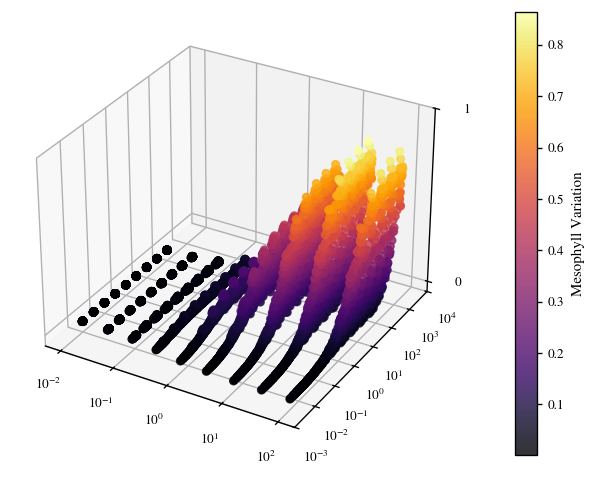

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import figure, use_style

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

paths = ProjectPaths(ProjectConfig().behavior.storage_root)
df = load_dataframe(paths.photoactive_summary.require())

use_style()


def log3d_scatter(ax, x, y, z, *, base=10, **scatter_kwargs):
    from matplotlib.ticker import FuncFormatter

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # mask = (x > 0) & (y > 0) & (z > 0)
    mask = np.ones_like(x, dtype=bool)

    if base == 10:
        (
            lx,
            ly,
        ) = np.log10(x[mask]), np.log10(y[mask])
        tick_label = lambda v: rf"$10^{{{int(v)}}}$"
    elif base == np.e:
        lx, ly = np.log(x[mask]), np.log(y[mask])
        tick_label = lambda v: rf"$e^{{{int(v)}}}$"
    else:
        lx = np.log(x[mask]) / np.log(base)
        ly = np.log(y[mask]) / np.log(base)
        tick_label = lambda v: rf"${base}^{{{int(v)}}}$"

    sc = ax.scatter(lx, ly, z, **scatter_kwargs)

    for axis, data in [
        (ax.xaxis, lx),
        (ax.yaxis, ly),
    ]:
        ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
        axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

    ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
    ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
    ax.set_zticks(np.arange(np.floor(z.min()), np.ceil(z.max()) + 1))

    formatter = FuncFormatter(lambda val, pos: tick_label(val))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    return sc


key = "mesophyll_variation"
z = df[key]

abs_eff = df["absorption"]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"].to_numpy(),
    df["transport"].to_numpy(),
    z,
    c=z,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label(key.title().replace("_", " "))
plt.show()
